In [ ]:
dataset link:https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

In [29]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers


In [31]:

dataset_path = 'C:\\Users\\Akhil M\\Downloads\Tumor\\Training'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(150, 150),  
    batch_size=32,
    validation_split=0.2, 
    subset="training",
    seed=42
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(150, 150),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)


class_names = train_ds.class_names
print("Classes:", class_names)


<>:1: SyntaxWarning: invalid escape sequence '\T'
<>:1: SyntaxWarning: invalid escape sequence '\T'
C:\Users\Akhil M\AppData\Local\Temp\ipykernel_27692\2884533730.py:1: SyntaxWarning: invalid escape sequence '\T'
  dataset_path = 'C:\\Users\\Akhil M\\Downloads\Tumor\\Training'


Found 5712 files belonging to 4 classes.
Using 4570 files for training.
Found 5712 files belonging to 4 classes.
Using 1142 files for validation.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


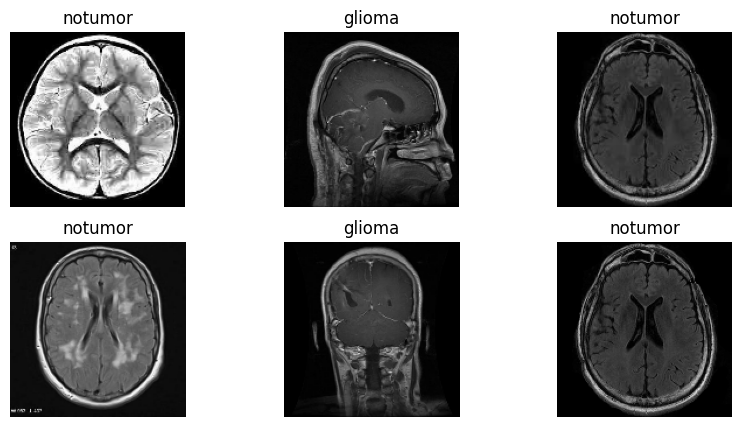

In [33]:
plt.figure(figsize=(10, 5))
for images, labels in train_ds.take(1):  # Take one batch
    for i in range(6):  # Show first 6 images
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [35]:
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [37]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])


In [39]:
model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(class_names), activation='softmax')  # Multi-class output
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])



In [41]:
history = model.fit(train_ds, validation_data=test_ds, epochs=10)


Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 270ms/step - accuracy: 0.4885 - loss: 1.1481 - val_accuracy: 0.7872 - val_loss: 0.6115
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 48s 334ms/step - accuracy: 0.7295 - loss: 0.6689 - val_accuracy: 0.8056 - val_loss: 0.5453
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 49s 343ms/step - accuracy: 0.7745 - loss: 0.5628 - val_accuracy: 0.6778 - val_loss: 0.8524
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 56s 389ms/step - accuracy: 0.8038 - loss: 0.4770 - val_accuracy: 0.6462 - val_loss: 1.1299
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 60s 421ms/step - accuracy: 0.8357 - loss: 0.4366 - val_accuracy: 0.8074 - val_loss: 0.5555
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 58s 405ms/step - accuracy: 0.8436 - loss: 0.4029 - val_accuracy: 0.8485 - val_loss: 0.4355
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 56s 393ms/step - accuracy: 0.8661 - loss: 0.3672 - val_accuracy: 0.7294 - val_loss: 0.8167
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 59s 413ms/step - accuracy: 0.8808 - loss: 0

In [43]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8718 - loss: 0.4314
Test Accuracy: 85.81%


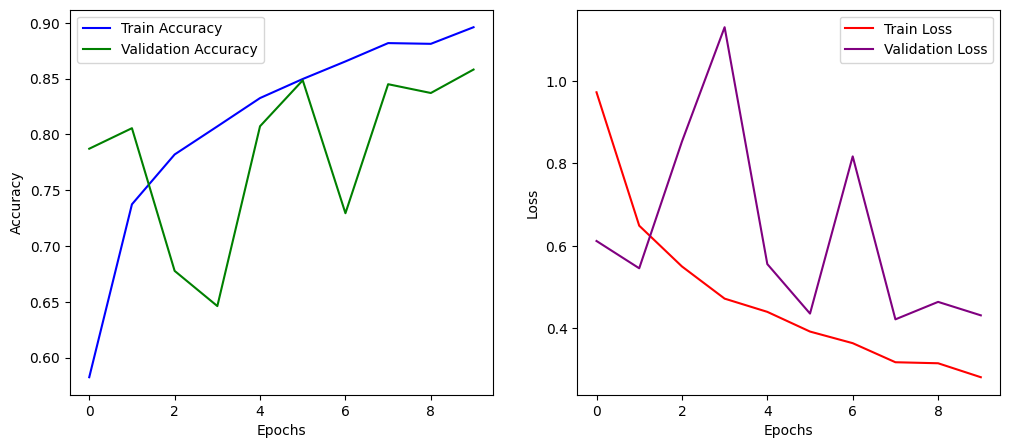

In [79]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='purple')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [107]:
def preprocess_image(img_path, img_size=(150, 150)):
    img = image.load_img(img_path, target_size=img_size) 
    img_array = image.img_to_array(img) 
    img_array = np.expand_dims(img_array, axis=0)  
    img_array /= 255.0  
    return img_array

new_image_path = r"C:\Users\Akhil M\Downloads\tumortest.jpg"
new_image = preprocess_image(new_image_path)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Class: notumor


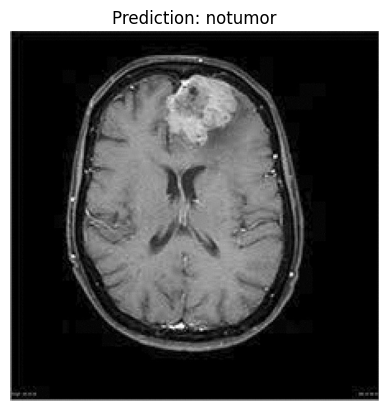

In [109]:
predictions = model.predict(new_image)

predicted_class = np.argmax(predictions[0])  
predicted_label = class_names[predicted_class]

print(f"Predicted Class: {predicted_label}")

plt.imshow(image.load_img(new_image_path))
plt.title(f"Prediction: {predicted_label}")
plt.axis("off")
plt.show()
